# Assignment Customer Satisfaction and Sentiment Analysis


## Objective

You are a data analyst of a consulting company that provides customer insight regarding multiple ticketing system, such as JIRA and Zoho Desk. Your team gather surveys to customers regarding their ticketing system's performance. Your role in the team is to gather reports regarding customer satisfaction and sentiment analysis into a single dashboard and present your insight.

Analyze the following metrics and other insight you can find in the dataset:

- Survey response rate
- Customer Satisfaction score (CSAT)
- Customer Effort Score (CES)
- Net Promoter Score (NPS)
- Sentiment Analysis



## Data Preparation

In [ ]:
import numpy as np
import pandas as pd
import os

pd.options.display.max_columns = 999
pd.options.display.float_format = "{:.2f}".format

### Dataset


In [ ]:
df_review = pd.read_csv('/content/assignment_ticket_system_review.csv')

### Read Data

Read the file **assignment_ticket_system_review.csv**

In [ ]:
# Read Data
df_review.head()

,id_survey,date_of_survey,ticket_system,overall_rating,customer_service,features,value_for_money,ease_of_use,likelihood_to_recommend,overall_text
0,T_02161,2024-11-20,Zendesk,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T_00229,2024-10-06,Zendesk,3.00,4.00,3.00,3.00,2.00,6.00,Customer tickets managements
2,T_04527,2024-12-26,Zoho Desk,5.00,5.00,5.00,5.00,5.00,8.00,"After 6 months of using the Zoho desk, we shif..."
3,T_03190,2024-12-08,Zoho Desk,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T_00644,2024-10-17,Zendesk,5.00,3.00,4.00,5.00,5.00,6.00,Pros:Zendesk has always been one of the go-to ...


The following is the dictionary for the data, survey is only valid if all of the survey questions and text review is not blank (null):

**General Information**
- id_survey: identifier for each survey
- date_of_survey: date of survey taken
- ticket_system: The name of the ticket system being reviewed (e.g. Zoho Desk)

**Survey Questions**
- overall_rating: The overall satisfaction rating given by the reviewer, ranging from 1 to 5
- customer_service: The satisfaction rating for the customer service provided by the ticket system, ranging from 1 to 5.
- features: The satisfaction rating for the features of the ticket system, ranging from 1 to 5
- value_for_money: The satisfaction rating for the value for money provided by the ticket system, ranging from 1 to 5
- ease_of_use: The rating for how easy the ticket system is to use, ranging from 1 to 5
- likelihood_to_recommend: The likelihood that the reviewer would recommend the ticket system to others, ranging from 1 to 10
- overall_text: The full text of the overall review, providing detailed feedback on the ticket system.


In [ ]:
# Check Data Description

df_review.describe()

,overall_rating,customer_service,features,value_for_money,ease_of_use,likelihood_to_recommend
count,787.00,787.00,787.00,787.00,787.00,787.00
mean,4.56,3.37,4.42,4.38,4.47,7.61
std,0.64,1.14,0.72,0.82,0.73,1.72
min,1.00,-1.00,1.00,1.00,1.00,-1.00
25%,4.00,3.00,4.00,4.00,4.00,7.00
50%,5.00,3.00,5.00,5.00,5.00,8.00
75%,5.00,4.00,5.00,5.00,5.00,9.00
max,5.00,5.00,5.00,5.00,5.00,10.00


In [ ]:
# Check the type of data
df_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_survey                1462 non-null   object 
 1   date_of_survey           1462 non-null   object 
 2   ticket_system            1462 non-null   object 
 3   overall_rating           787 non-null    float64
 4   customer_service         787 non-null    float64
 5   features                 787 non-null    float64
 6   value_for_money          787 non-null    float64
 7   ease_of_use              787 non-null    float64
 8   likelihood_to_recommend  787 non-null    float64
 9   overall_text             787 non-null    object 
dtypes: float64(6), object(4)
memory usage: 114.3+ KB




---


Interpretation:

* Terdapat total 1462 tiket/entri.
* Dari jumlah itu, hanya 787 entri yang memiliki data survey kepuasan.

### Data Cleansing

Convert the date column into proper date_time format.

In [ ]:
# Convert data type
df_review['date_of_survey'] = pd.to_datetime(df_review['date_of_survey'])

df_review.head()

,id_survey,date_of_survey,ticket_system,overall_rating,customer_service,features,value_for_money,ease_of_use,likelihood_to_recommend,overall_text
0,T_02161,2024-11-20,Zendesk,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T_00229,2024-10-06,Zendesk,3.00,4.00,3.00,3.00,2.00,6.00,Customer tickets managements
2,T_04527,2024-12-26,Zoho Desk,5.00,5.00,5.00,5.00,5.00,8.00,"After 6 months of using the Zoho desk, we shif..."
3,T_03190,2024-12-08,Zoho Desk,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T_00644,2024-10-17,Zendesk,5.00,3.00,4.00,5.00,5.00,6.00,Pros:Zendesk has always been one of the go-to ...


In [ ]:
#Check - apakah date_of_survey datanya sudah berubah dari objek ke datetime

df_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id_survey                1462 non-null   object        
 1   date_of_survey           1462 non-null   datetime64[ns]
 2   ticket_system            1462 non-null   object        
 3   overall_rating           787 non-null    float64       
 4   customer_service         787 non-null    float64       
 5   features                 787 non-null    float64       
 6   value_for_money          787 non-null    float64       
 7   ease_of_use              787 non-null    float64       
 8   likelihood_to_recommend  787 non-null    float64       
 9   overall_text             787 non-null    object        
dtypes: datetime64[ns](1), float64(6), object(3)
memory usage: 114.3+ KB


## Survey Analysis

### Response Rate

Start by analyzing how many customers has filled the survey, indicated by whether the overall_rating is not blank.

In [ ]:
# How many customer responded to the survey?
df_review['fill_survey'] = np.where(df_review['overall_rating'].isnull(), 'Not Responded', 'Responded')

df_review.value_counts('fill_survey', normalize = True).reset_index()

,fill_survey,proportion
0,Responded,0.54
1,Not Responded,0.46


Create a new dataframe that consists only of those who have responded the survey to simplify calculating the CSAT, CES, and NPS Score.

In [ ]:
# Responded Customer
responded_customer = df_review[ df_review['fill_survey'] == 'Responded'].copy()

### CSAT Score

Measure the customer's overall satisfaction score (CSAT) with the following formula:

$$
CSAT = \frac{\Sigma\ total\ satisfaction\ score}{number\ of\ responded\ customer \times \max\ rating}
$$

The max rating is inserted to convert the CSAT score into percentage.

CSAT score can be classified into categories based on the result. There is no absolute threshold for each categories but the following is the common threshold:

- \>= 90%: Excellent
- 75%-90%: Good
- 60-75%: Fair
- \<60%: Poor

In [ ]:
# CSAT Score

max_rating = 5
n_data = (responded_customer.shape[0] * max_rating)  #-- number of responded customer x max rating

csat_score = responded_customer['overall_rating'].sum() / n_data

print(f'Overall CSAT Score: { (csat_score * 100):.1f}%')

Overall CSAT Score: 91.2%


Measure the satisfaction score for the following attributes:

- customer service
- features
- value for money

In [ ]:
# Satisfaction Score for Attributes
score_customer_service = responded_customer['customer_service'].sum() / n_data
score_features = responded_customer['features'].sum()/ n_data
score_value_for_money = responded_customer['value_for_money'].sum()/ n_data

print(f'Overall CSAT Score: { (csat_score * 100):.1f}%')
print(f'Customer Service of Ticket System: { (score_customer_service * 100):.1f}%')
print(f'Features of Ticket System: { (score_features * 100):.1f}%')
print(f'Value for Money of Ticket System: { (score_value_for_money * 100):.1f}%')

Overall CSAT Score: 91.2%
Customer Service of Ticket System: 67.3%
Features of Ticket System: 88.3%
Value for Money of Ticket System: 87.6%


### CES Score

Measure CES with the following formula


$$
CES = \frac{\Sigma\ total\ effort\ score}{number\ of\ responded\ customer \times \max\ rating}
$$

In [ ]:
# CES Score

max_rating = 5

ces_ease_of_use = responded_customer['ease_of_use'].sum()/ n_data

print(f'Ease of Use CES Score: { (ces_ease_of_use * 100):.1f}%')


Ease of Use CES Score: 89.5%


### NPS Score

To calculate the NPS score, first we must convert the **would_you_recommend** column into proper NPS Category based on the rating value:

* Promoter: Rating 9-10
* Passive: Rating 7-8
* Detractor: Rating < 7

In [ ]:
# Category NPS
nps_value = ['Promoter', 'Passive', 'Detractor']
nps_condition = [responded_customer['likelihood_to_recommend'] >= 9,
                 (responded_customer['likelihood_to_recommend'] >= 7) & (responded_customer['likelihood_to_recommend'] < 9),
                 responded_customer['likelihood_to_recommend'] < 7
                 ]

responded_customer['nps_category'] = np.select(nps_condition, nps_value, default='')

responded_customer.value_counts('nps_category', normalize = True)

,proportion
nps_category,
Passive,0.48
Promoter,0.32
Detractor,0.20



Calculate the NPS Score with the following formula

$$
NPS = \frac{Promoter - Detractor}{Total\ Survey\ Responded}
$$

In [ ]:
# NPS Score
nps_agg_1 = responded_customer.value_counts('nps_category').reset_index()

nps_agg_promoter = nps_agg_1[ nps_agg_1['nps_category'] == 'Promoter' ]['count'].item()
nps_agg_detractor = nps_agg_1[ nps_agg_1['nps_category'] == 'Detractor' ]['count'].item()
nps_score = (nps_agg_promoter - nps_agg_detractor)/nps_agg_1['count'].sum()

print(f'NPS Score: { (nps_score * 100):.1f}')

NPS Score: 11.9


NPS score can be ranging from -100 (when all customers are detractor) to 100 (when all customers are promoter).

NPS Score can be classified into categories based on the following threshold:

- \>= 70: Excellent
- 50-69: Very Good
- 30-49: Good
- 0-29: Average
- \< 0: Poor

## Sentiment Analysis

Create a new dataframe with no blank overall_text.

In [ ]:
# Create new dataframe
df_review = df_review.merge(responded_customer[['id_survey', 'nps_category']], on = 'id_survey', how = 'left')

df_review.head()

,id_survey,date_of_survey,ticket_system,overall_rating,customer_service,features,value_for_money,ease_of_use,likelihood_to_recommend,overall_text,fill_survey,nps_category
0,T_02161,2024-11-20,Zendesk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Responded,NaN
1,T_00229,2024-10-06,Zendesk,3.00,4.00,3.00,3.00,2.00,6.00,Customer tickets managements,Responded,Detractor
2,T_04527,2024-12-26,Zoho Desk,5.00,5.00,5.00,5.00,5.00,8.00,"After 6 months of using the Zoho desk, we shif...",Responded,Passive
3,T_03190,2024-12-08,Zoho Desk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Responded,NaN
4,T_00644,2024-10-17,Zendesk,5.00,3.00,4.00,5.00,5.00,6.00,Pros:Zendesk has always been one of the go-to ...,Responded,Detractor


### Text Cleansing

In order to get more accurate sentiment, several text cleansing need to be done. However, in most of recent sentiment analysis models and algorithm, the only text cleansing needed are as follows:

* Clean double whitespace
* Clean URL/website
* Clean username (mostly in social media or digital text)

In [ ]:
import re

def cleansing_text(x):
  # clean double whitespace
  out_text = ' '.join(x.split())

  # clean url
  out_text = re.sub(r"http\S+|www\S+|https\S+", 'http', out_text)

  # clean username
  out_text = re.sub(r"@\S+", '@user', out_text)

  return(out_text)

cleansing_text(" Doesn't  dissapoint. The Our Ticket System       was great. It was the best car rental experiences I've had! Salute to @jone who recommend https:/KaiichiTickets.com")

"Doesn't dissapoint. The Our Ticket System was great. It was the best car rental experiences I've had! Salute to @user who recommend http"

In [ ]:
# Create new dataframe with no blank overall_text
df_review_clean = df_review[df_review['overall_text'].notna()].copy()

# apply cleansing to review
df_review_clean['clean_text'] = df_review_clean['overall_text'].apply(cleansing_text)

df_review_clean.tail()

,id_survey,date_of_survey,ticket_system,overall_rating,customer_service,features,value_for_money,ease_of_use,likelihood_to_recommend,overall_text,fill_survey,nps_category,clean_text
1457,T_01536,2024-11-08,Freshdesk,5.00,4.00,4.00,5.00,5.00,8.00,"IT was not prioritizing, tracking, resolving a...",Responded,Passive,"IT was not prioritizing, tracking, resolving a..."
1458,T_00582,2024-10-15,Jira Service Management,4.00,3.00,3.00,4.00,4.00,5.00,"Very useful, one-stop solution with related to...",Responded,Detractor,"Very useful, one-stop solution with related to..."
1459,T_01834,2024-11-14,Zendesk,5.00,4.00,5.00,5.00,5.00,10.00,We have done quite well. We have already more ...,Responded,Promoter,We have done quite well. We have already more ...
1460,T_03629,2024-12-13,Zendesk,5.00,3.00,5.00,5.00,4.00,7.00,"Immensely positive, highly recommended custome...",Responded,Passive,"Immensely positive, highly recommended custome..."
1461,T_01981,2024-11-17,Zoho Desk,4.00,4.00,4.00,4.00,3.00,7.00,Pros:Easy to start with a basic free setup and...,Responded,Passive,Pros:Easy to start with a basic free setup and...


In [ ]:
df_review_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 787 entries, 1 to 1461
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id_survey                787 non-null    object        
 1   date_of_survey           787 non-null    datetime64[ns]
 2   ticket_system            787 non-null    object        
 3   overall_rating           787 non-null    float64       
 4   customer_service         787 non-null    float64       
 5   features                 787 non-null    float64       
 6   value_for_money          787 non-null    float64       
 7   ease_of_use              787 non-null    float64       
 8   likelihood_to_recommend  787 non-null    float64       
 9   overall_text             787 non-null    object        
 10  fill_survey              787 non-null    object        
 11  nps_category             787 non-null    object        
 12  clean_text               787 non-null   

### Sentiment Analysis

Create a sentiment categories using algorithm of your own choice.

In [ ]:
# Sentiment Algorithm
%%capture
!pip install transformers
from transformers import pipeline

# sentiment analysis task with twitter roberta model
sentiment_pipeline = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

Check the number of data by sentiment.

In [ ]:
# Number of Sentiment
%%time
# Predict sentiment
transformer_results = sentiment_pipeline(df_review_clean['clean_text'].tolist())

df_review_clean['sentiment_score'] = transformer_results
df_review_clean['sentiment'] = df_review_clean['sentiment_score'].apply(lambda x: x['label'])

# Create sentiment category
sent_value = ['Negative', 'Neutral', 'Positive']
sent_condition = [df_review_clean['sentiment'] == 'LABEL_0',
                  df_review_clean['sentiment'] == 'LABEL_1',
                  df_review_clean['sentiment'] == 'LABEL_2'
                  ]

df_review_clean['sentiment'] = np.select(sent_condition, sent_value, default='Unknown')

df_review_clean.head()

CPU times: user 10.2 s, sys: 25.2 ms, total: 10.2 s
Wall time: 14.8 s


,id_survey,date_of_survey,ticket_system,overall_rating,customer_service,features,value_for_money,ease_of_use,likelihood_to_recommend,overall_text,fill_survey,nps_category,clean_text,sentiment_score,sentiment
1,T_00229,2024-10-06,Zendesk,3.00,4.00,3.00,3.00,2.00,6.00,Customer tickets managements,Responded,Detractor,Customer tickets managements,"{'label': 'LABEL_1', 'score': 0.732880175113678}",Neutral
2,T_04527,2024-12-26,Zoho Desk,5.00,5.00,5.00,5.00,5.00,8.00,"After 6 months of using the Zoho desk, we shif...",Responded,Passive,"After 6 months of using the Zoho desk, we shif...","{'label': 'LABEL_2', 'score': 0.9796792268753052}",Positive
4,T_00644,2024-10-17,Zendesk,5.00,3.00,4.00,5.00,5.00,6.00,Pros:Zendesk has always been one of the go-to ...,Responded,Detractor,Pros:Zendesk has always been one of the go-to ...,"{'label': 'LABEL_2', 'score': 0.7879296541213989}",Positive
6,T_04682,2024-12-28,Zoho Desk,5.00,4.00,5.00,5.00,5.00,8.00,It has been very useful so far to integrate mu...,Responded,Passive,It has been very useful so far to integrate mu...,"{'label': 'LABEL_2', 'score': 0.9632710218429565}",Positive
8,T_01238,2024-11-02,Freshdesk,4.00,4.00,4.00,5.00,4.00,8.00,Pros:It's easy to use and very intuitive.We ha...,Responded,Passive,Pros:It's easy to use and very intuitive.We ha...,"{'label': 'LABEL_2', 'score': 0.8690707683563232}",Positive


Check the number of data by sentiment.

In [ ]:
df_review_clean.value_counts('sentiment')

,count
sentiment,
Positive,667
Neutral,100
Negative,20


## Finalize Data for Reporting

Save the review data with NPS category and sentiment information to new csv for the dashboard.

In [ ]:
df_review_final = df_review.merge(df_review_clean[['id_survey', 'sentiment']],
                                  on = 'id_survey', how = 'left'
                                  )

df_review_final.head()

,id_survey,date_of_survey,ticket_system,overall_rating,customer_service,features,value_for_money,ease_of_use,likelihood_to_recommend,overall_text,fill_survey,nps_category,sentiment
0,T_02161,2024-11-20,Zendesk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Responded,NaN,NaN
1,T_00229,2024-10-06,Zendesk,3.00,4.00,3.00,3.00,2.00,6.00,Customer tickets managements,Responded,Detractor,Neutral
2,T_04527,2024-12-26,Zoho Desk,5.00,5.00,5.00,5.00,5.00,8.00,"After 6 months of using the Zoho desk, we shif...",Responded,Passive,Positive
3,T_03190,2024-12-08,Zoho Desk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Responded,NaN,NaN
4,T_00644,2024-10-17,Zendesk,5.00,3.00,4.00,5.00,5.00,6.00,Pros:Zendesk has always been one of the go-to ...,Responded,Detractor,Positive


In [ ]:
# NPS Score
nps_score = (responded_customer.value_counts('nps_category', normalize=True)['Promoter'] - responded_customer.value_counts('nps_category', normalize=True)['Detractor']) * 100

print(f'NPS Score: {nps_score:.1f}')

NPS Score: 11.9


In [ ]:
# Save the final dataframe to a csv file
df_review_final.to_csv('assignment_ticket_system_review_final.csv', index=False)

## Extra: Tokenize Text

Another interesting things that we can do with text data is collecting the word or token and look for any insight based on the most frequent words that appear on each sentiment.

We will split the text of each comment into a word or token, called as **Tokenization**, in order to visualize the data.

In [ ]:
%%capture
import nltk

# Download stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

!pip install contractions

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import contractions

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Create more detailed text cleansing
def clean_tokenize_text(x):
  # lower text
  out_text = x.lower()
  # clean double whitespace
  out_text = ' '.join(out_text.split())
  # clean url
  out_text = re.sub(r"http\S+|www\S+|https\S+", 'http', out_text)
  # clean username
  out_text = re.sub(r"@\S+", '@user', out_text)
  # remove punctuation
  out_text = out_text.translate(str.maketrans('', '', string.punctuation))
  # fix word contraction: don't -> do not
  out_text = contractions.fix(out_text)
  # tokenize the text
  tokens = word_tokenize(out_text)
  # exclude stop words
  tokens = [word for word in tokens if word not in stop_words]
  # lematize tokens: cats -> cat
  tokens = [lemmatizer.lemmatize(word) for word in tokens]

  return(tokens)

In [ ]:
# Example
clean_tokenize_text('This   product sparks joy. You should try it!')

['product', 'spark', 'joy', 'try']

Apply the tokenization to the whole dataset.

In [ ]:
%%time
df_review_token = df_review_clean[['id_survey', 'sentiment', 'overall_text']].copy()

df_review_token['token'] = df_review_token['overall_text'].apply(clean_tokenize_text)

df_review_token = df_review_token.explode('token')

df_review_token = df_review_token[['id_survey', 'token', 'sentiment']]

df_review_token.head()

CPU times: user 293 ms, sys: 0 ns, total: 293 ms
Wall time: 614 ms


,id_survey,token,sentiment
1,T_00229,customer,Neutral
1,T_00229,ticket,Neutral
1,T_00229,management,Neutral
2,T_04527,6,Positive
2,T_04527,month,Positive


In [ ]:
# Save to csv
df_review_token.to_csv('tokenized_text.csv', index = False)


### Text Visualization: Word Cloud

Create a simple word cloud for the top 50 words of each sentiment.

In [ ]:
# Only check for positive and negative sentiment
df_top_word = df_review_token[ df_review_token['sentiment'] != 'Neutral' ]
df_top_word = df_top_word.groupby(['sentiment', 'token']).agg({'id_survey':'nunique'}).reset_index()

# Get top 50 words
df_top_word = df_top_word.sort_values(['sentiment', 'id_survey'], ascending = [False, False])
df_top_word = df_top_word.groupby('sentiment').head(50)

df_top_word.head()

,sentiment,token,id_survey
698,Positive,customer,181
2419,Positive,use,158
2230,Positive,support,155
839,Positive,easy,143
2326,Positive,tool,106


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

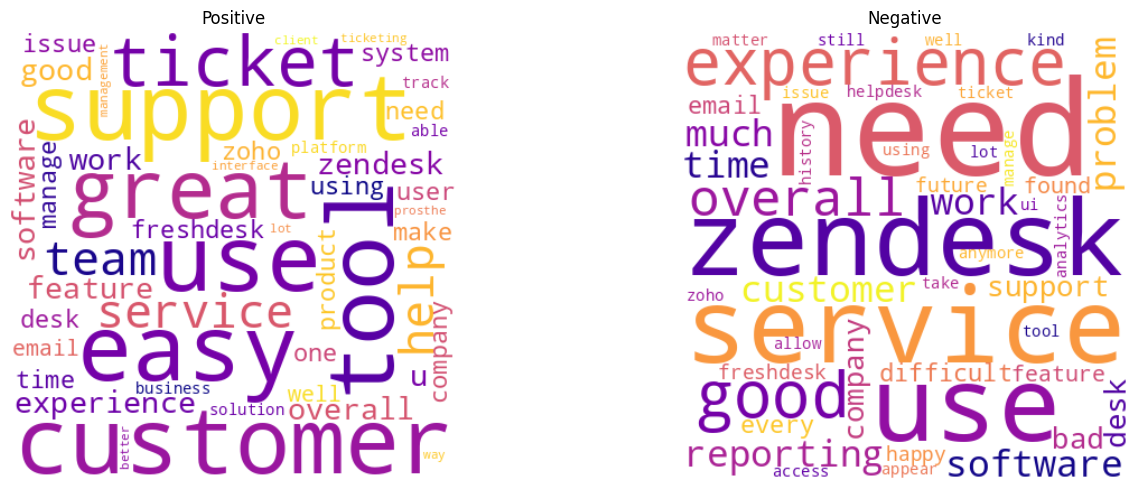

In [ ]:
groups = df_top_word['sentiment'].unique()

# Set up the plot
fig, axes = plt.subplots(1, len(groups), figsize=(15, 5), squeeze=False)

# Generate word clouds for each group
for idx, group in enumerate(groups):
    text = " ".join(df_top_word[ df_top_word['sentiment'] == group]['token'])
    wordcloud = WordCloud(width=400, height=400,
                          background_color='white',
                          colormap = 'plasma'
                          ).generate(text)

    # Display the word cloud
    axes[0, idx].imshow(wordcloud, interpolation='bilinear')
    axes[0, idx].set_title(f"{group}")
    axes[0, idx].axis('off')

plt.tight_layout()
plt.show()

### Tokenize with Bi-gram

Instead of tokenize the sentence into words, you can represent each token as a bigram, a pair of consecutive words. For example, the sentence *I love this apple* will be tokenized into the followings:

* I love
* love this
* this apple

If the stopwords are cleansed, it will remove the *I* and *this* word, so it will only return a single bigram: love apple

In [ ]:
from nltk.util import bigrams

def clean_tokenize_bigram(x):
  # lower text
  out_text = x.lower()
  # clean double whitespace
  out_text = ' '.join(out_text.split())
  # clean url
  out_text = re.sub(r"http\S+|www\S+|https\S+", 'http', out_text)
  # clean username
  out_text = re.sub(r"@\S+", '@user', out_text)
  # remove punctuation
  out_text = out_text.translate(str.maketrans('', '', string.punctuation))
  # fix word contraction: don't -> do not
  out_text = contractions.fix(out_text)
  # tokenize the text
  tokens = word_tokenize(out_text)
  # exclude stop words
  tokens = [word for word in tokens if word not in stop_words]
  # lematize tokens: cats -> cat
  tokens = [lemmatizer.lemmatize(word) for word in tokens]

  # Create bigrams
  tokens = list(bigrams(tokens))

  # Join bigrams into single strings
  tokens = ['_'.join(pair) for pair in tokens]

  return(tokens)

clean_tokenize_bigram("I love this apple")


['love_apple']

In [ ]:
%%time
df_review_token = df_review_clean[['id_survey', 'sentiment', 'overall_text']].copy()

df_review_token['token'] = df_review_token['overall_text'].apply(clean_tokenize_bigram)

df_review_token = df_review_token.explode('token')

df_review_token = df_review_token[['id_survey', 'token', 'sentiment']]

df_review_token.head()

CPU times: user 218 ms, sys: 946 µs, total: 219 ms
Wall time: 243 ms


,id_survey,token,sentiment
1,T_00229,customer_ticket,Neutral
1,T_00229,ticket_management,Neutral
2,T_04527,6_month,Positive
2,T_04527,month_using,Positive
2,T_04527,using_zoho,Positive


In [ ]:
# Only check for positive and negative sentiment
df_top_word = df_review_token[ df_review_token['sentiment'] != 'Neutral' ]
df_top_word = df_top_word.groupby(['sentiment', 'token']).agg({'id_survey':'nunique'}).reset_index()

# Get top 20 phrases
df_top_word = df_top_word.sort_values(['sentiment', 'id_survey'], ascending = [False, False])
df_top_word = df_top_word.groupby('sentiment').head(20)

df_top_word.head()

,sentiment,token,id_survey
2415,Positive,easy_use,54
1936,Positive,customer_support,44
1928,Positive,customer_service,40
9109,Positive,zoho_desk,28
5370,Positive,overall_experience,20


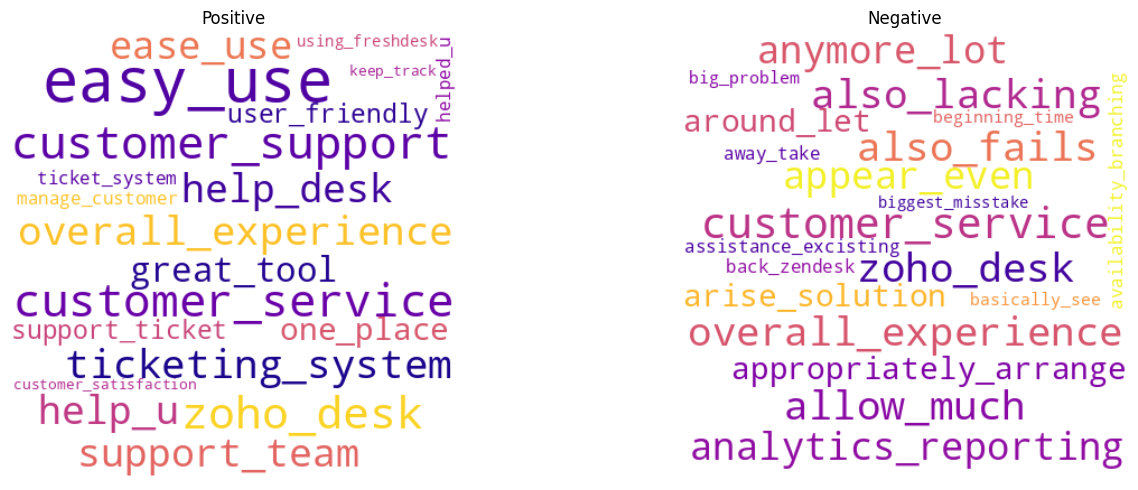

In [ ]:
groups = df_top_word['sentiment'].unique()

# Set up the plot
fig, axes = plt.subplots(1, len(groups), figsize=(15, 5), squeeze=False)

# Generate word clouds for each group
for idx, group in enumerate(groups):
    text = " ".join(df_top_word[ df_top_word['sentiment'] == group]['token'])
    wordcloud = WordCloud(width=400, height=400,
                          background_color='white',
                          colormap = 'plasma'
                          ).generate(text)

    # Display the word cloud
    axes[0, idx].imshow(wordcloud, interpolation='bilinear')
    axes[0, idx].set_title(f"{group}")
    axes[0, idx].axis('off')

plt.tight_layout()
plt.show()